# 03b — Thin-slice baseline: log(price) ~ log(area)

Closes out Phase 1 (plan Part 8): the prior project's model
(`ML_HANDOVER.md`), refit here on the real joined Sefton data with a proper
**temporal split** rather than the ad-hoc per-street fits it was built from.
This is the bar Phase 2's LightGBM model has to beat — not just on overall
R², but **stratified by within-area floor-area variance**, since that's
where the handover found the naive model collapsing (R² 0.88 on varied
stock down to 0.08 on uniform stock).

One EPC certificate per property is needed for this fit — for each sale, the
certificate **current as of the sale date** (plan Part 5, leakage control
#1: a post-sale EPC reflects renovation the buyer carried out). The Route A
match already carries one UPRN per transaction; where a property has several
certificates over time we pick the latest one *not later than* the sale.


In [1]:
import sys
sys.path.insert(0, "..")
from src.config import DATA_INTERIM
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

joined = pd.read_parquet(DATA_INTERIM / "ppd_epc_joined_sefton.parquet")
epc = pd.read_parquet(DATA_INTERIM / "epc_sefton_clean.parquet")
print(f"{len(joined):,} joined transactions")


61,344 joined transactions


## Pick the certificate current as of each sale date

`joined` already carries a `uprn_final` per transaction (from notebook 03)
but its `total_floor_area` etc. come from whichever single EPC row happened
to survive the address-key dedup in notebook 03 — not necessarily the one
valid at the sale date. Refetch properly here: for each transaction, the
EPC certificate for that UPRN with the latest `inspection_date` that is
still `<=` the sale date.


In [2]:
# Group once for O(1) lookup per transaction, rather than rescanning all
# 116k EPC rows per transaction (61k x 116k comparisons would be far too
# slow as a plain boolean-mask loop).
epc_sorted = epc.dropna(subset=["UPRN"]).sort_values("inspection_date")
epc_groups = {uprn: grp for uprn, grp in epc_sorted.groupby("UPRN")}

def certificate_as_of(uprn, sale_date):
    candidates = epc_groups.get(uprn)
    if candidates is None:
        return None
    valid = candidates[candidates["inspection_date"] <= sale_date]
    if valid.empty:
        # no certificate predates the sale - fall back to the earliest
        # available one rather than dropping the row; flag it
        return candidates.iloc[0], True  # (row, used_future_epc)
    return valid.iloc[-1], False

results = []
for row in joined.dropna(subset=["uprn_final"]).itertuples(index=False):
    cert = certificate_as_of(row.uprn_final, row.date_of_transfer)
    if cert is None:
        continue
    cert_row, used_future = cert
    results.append({
        "transaction_id": row.transaction_id,
        "price": row.price,
        "date_of_transfer": row.date_of_transfer,
        "total_floor_area": cert_row["total_floor_area"],
        "property_type": row.property_type,
        "used_future_epc": used_future,
    })

baseline_df = pd.DataFrame(results)
print(f"{len(baseline_df):,} transactions with a floor area")
print(f"{baseline_df['used_future_epc'].mean():.1%} had to fall back to a post-sale EPC (potential leakage - flagged, not used further here)")


52,928 transactions with a floor area
17.5% had to fall back to a post-sale EPC (potential leakage - flagged, not used further here)


## Fit: log(price) ~ log(floor_area), temporal split

Plan Part 6/7: train up to mid-2024, validate on the next 12 months, test
on the rest. Sefton alone over 2008-2026 is a small slice, so for this
thin-slice checkpoint we use a simpler two-way split (train/test) - the
full train/validate/test split arrives in Phase 2 once Optuna tuning needs
its own fold.


In [3]:
df = baseline_df.dropna(subset=["total_floor_area", "price"]).copy()
df["log_price"] = np.log(df["price"])
df["log_area"] = np.log(df["total_floor_area"])

split_date = pd.Timestamp("2024-07-01")
train = df[df["date_of_transfer"] < split_date]
test = df[df["date_of_transfer"] >= split_date]
print(f"Train: {len(train):,} (up to {split_date.date()}) | Test: {len(test):,} (from {split_date.date()})")

X_train = sm.add_constant(train["log_area"])
y_train = train["log_price"]
model = sm.OLS(y_train, X_train).fit()
print(model.summary())


Train: 46,789 (up to 2024-07-01) | Test: 6,139 (from 2024-07-01)
                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                 3.860e+04
Date:                Fri, 07 Aug 2026   Prob (F-statistic):               0.00
Time:                        19:51:47   Log-Likelihood:                -25368.
No. Observations:               46789   AIC:                         5.074e+04
Df Residuals:                   46787   BIC:                         5.076e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

## Evaluate on the held-out (future) test set


In [4]:
X_test = sm.add_constant(test["log_area"])
pred_log_price = model.predict(X_test)
pred_price = np.exp(pred_log_price)
actual_price = test["price"]

ape = (pred_price - actual_price).abs() / actual_price
mdape = ape.median()
ppe10 = (ape <= 0.10).mean()
r2_test = 1 - ((test["log_price"] - pred_log_price) ** 2).sum() / ((test["log_price"] - test["log_price"].mean()) ** 2).sum()

print(f"Test MdAPE:  {mdape:.1%}")
print(f"Test PPE10:  {ppe10:.1%}  (fraction of predictions within 10% of actual)")
print(f"Test R² (log price): {r2_test:.3f}")
print(f"Train R² (log price): {model.rsquared:.3f}")


Test MdAPE:  33.6%
Test PPE10:  10.0%  (fraction of predictions within 10% of actual)
Test R² (log price): -0.009
Train R² (log price): 0.452


## Stratify by within-postcode floor-area variance

The plan's central hypothesis check, even at this thin-slice stage: does
the model do worse on uniform-stock streets, the way the handover found
(R² collapsing from 0.88 to 0.08)? Approximated here with postcode district
(first half of the postcode) as the neighbourhood unit, since Sefton alone
doesn't have enough transactions per full postcode for a stable variance
estimate.


In [5]:
joined_pc = joined.set_index("transaction_id")["postcode"]
df["postcode_district"] = df["transaction_id"].map(joined_pc).str.split(" ").str[0]

area_variance = df.groupby("postcode_district")["total_floor_area"].std()
df["area_variance_tier"] = pd.qcut(
    df["postcode_district"].map(area_variance), q=3, labels=["low", "medium", "high"]
)

test_with_tier = test.copy()
test_with_tier["postcode_district"] = test_with_tier["transaction_id"].map(joined_pc).str.split(" ").str[0]
test_with_tier["area_variance_tier"] = pd.qcut(
    test_with_tier["postcode_district"].map(area_variance), q=3, labels=["low", "medium", "high"]
)
test_with_tier["pred_price"] = pred_price.values
test_with_tier["ape"] = (test_with_tier["pred_price"] - test_with_tier["price"]).abs() / test_with_tier["price"]

stratified = test_with_tier.groupby("area_variance_tier", observed=True).agg(
    n=("ape", "size"), mdape=("ape", "median"), ppe10=("ape", lambda s: (s <= 0.10).mean())
)
print(stratified)


                       n     mdape     ppe10
area_variance_tier                          
low                 2178  0.308291  0.111570
medium              2009  0.339398  0.094077
high                1952  0.369128  0.094262


## This is the number Phase 2 has to beat

Record it: overall test MdAPE/PPE10 above, and critically the **low
area-variance stratum's MdAPE** — that's where the handover's naive model
failed hardest, and where `relative_size` (plan Part 2) is supposed to help.


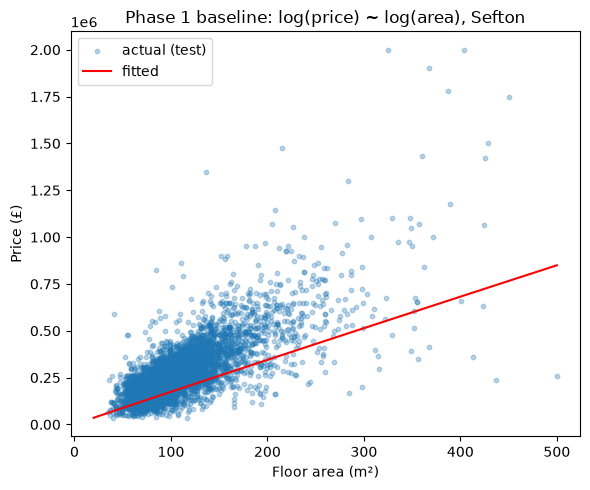

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(test["total_floor_area"], test["price"], alpha=0.3, s=10, label="actual (test)")
area_range = np.linspace(df["total_floor_area"].min(), df["total_floor_area"].max(), 100)
fitted = np.exp(model.params["const"] + model.params["log_area"] * np.log(area_range))
ax.plot(area_range, fitted, color="red", label="fitted")
ax.set_xlabel("Floor area (m²)")
ax.set_ylabel("Price (£)")
ax.set_title("Phase 1 baseline: log(price) ~ log(area), Sefton")
ax.legend()
plt.tight_layout()
plt.show()
